<a href="https://colab.research.google.com/github/Pujari5555/AI-ML/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Sentiment Analysis on Movie Reviews**

In [ ]:
import nltk
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from string import punctuation
from nltk.corpus import stopwords
from collections import Counter
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, LSTM, Embedding, Bidirectional, BatchNormalization
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.utils import shuffle, resample

#Load File

In [ ]:
train_path='/content/gdrive/MyDrive/MyCNN/ANN_PROJECT.csv'
test_path='/content/gdrive/MyDrive/MyCNN/ANN_PROJECT.csv'


#shapes of training and testing dataset

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
train_path.shape, test_path.shape

AttributeError: ignored

#datatype of training data

In [ ]:
train.dtypes

PhraseId       int64
SentenceId     int64
Phrase        object
Sentiment      int64
dtype: object

#datatype of testing data

In [ ]:
test.dtypes

PhraseId       int64
SentenceId     int64
Phrase        object
dtype: object

#Exploratory Data Analysis

* EDA helps us understand the data effectively and perhaps helps us create features and transforms for all the next steps. Visualizations are important to understand the feature distributions and check for data imbalances and feature interactions.

In [ ]:
labels=train.Sentiment

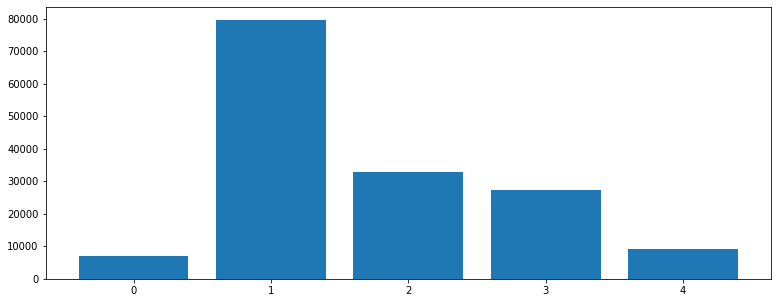

In [ ]:
plt.figure(figsize=(13,5))
plt.bar(height=train.Sentiment.value_counts(), x=train.Sentiment.unique())
plt.show()

#Data PreProcessing

* Get the Phrase into a list, for easy text cleanup and manipulation

In [ ]:
raw_phrases = train.Phrase.values
raw_phrases[0]

'A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .'

* Using regular expressions, remove IP addresses and URLs

In [ ]:
phrases_ip_remove = [re.sub(r'((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)(\.|$)){4}', '', text) for text in raw_phrases]
phrases_ip_remove[0]

'A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .'

* Using regular expressions, remove special characters

In [ ]:
phrases_spl_remove = [re.sub('[^A-Za-z \']+', '', text) for text in phrases_ip_remove]
phrases_spl_remove[0]

'A series of escapades demonstrating the adage that what is good for the goose is also good for the gander  some of which occasionally amuses but none of which amounts to much of a story '

* Normalize the casing

In [ ]:
phrases_lower=[text.lower() for text in phrases_spl_remove]
phrases_lower[0]

'a series of escapades demonstrating the adage that what is good for the goose is also good for the gander  some of which occasionally amuses but none of which amounts to much of a story '

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

* Tokenize using word_tokenize from NLTK

In [ ]:
phrases_word_tok0=[word_tokenize(text) for text in phrases_lower]
phrases_word_tok0[0]

['a',
 'series',
 'of',
 'escapades',
 'demonstrating',
 'the',
 'adage',
 'that',
 'what',
 'is',
 'good',
 'for',
 'the',
 'goose',
 'is',
 'also',
 'good',
 'for',
 'the',
 'gander',
 'some',
 'of',
 'which',
 'occasionally',
 'amuses',
 'but',
 'none',
 'of',
 'which',
 'amounts',
 'to',
 'much',
 'of',
 'a',
 'story']

* Remove punctuation single quote

In [ ]:
phrases_word_tok=[]
for words in phrases_word_tok0:
    phrases_word_tok.append([word for word in words if word not in punctuation])
phrases_word_tok[0]

['a',
 'series',
 'of',
 'escapades',
 'demonstrating',
 'the',
 'adage',
 'that',
 'what',
 'is',
 'good',
 'for',
 'the',
 'goose',
 'is',
 'also',
 'good',
 'for',
 'the',
 'gander',
 'some',
 'of',
 'which',
 'occasionally',
 'amuses',
 'but',
 'none',
 'of',
 'which',
 'amounts',
 'to',
 'much',
 'of',
 'a',
 'story']

* Flatten

In [ ]:
cleaned_phrases_train=[]
for text in phrases_word_tok:
    cleaned_phrases_train.append(" ".join(word for word in text))
cleaned_phrases_train[0]

'a series of escapades demonstrating the adage that what is good for the goose is also good for the gander some of which occasionally amuses but none of which amounts to much of a story'

* validation set

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(cleaned_phrases_train, labels, test_size=0.10, random_state=10)

* Training features and labels
* Padding Sequences

In [ ]:
labels=train.Sentiment.values
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(x_train)
sequences = tokenizer.texts_to_sequences(x_train)
x_train=pad_sequences(sequences, maxlen=200)
sequences = tokenizer.texts_to_sequences(x_val)
x_val=pad_sequences(sequences, maxlen=200)
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((140454, 200), (140454,), (15606, 200), (15606,))

* Function for Preprocessing for test data




In [ ]:
def Preprocess(test):

    #Get the Phrase into a list, for easy text cleanup and manipulation
    raw_phrases = test.Phrase.values

    #Using regular expressions, remove URLs
    phrases_ip_remove = [re.sub(r'((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)(\.|$)){4}', '', text) for text in raw_phrases]


    #Using regular expressions, remove special characters
    phrases_spl_remove = [re.sub('[^A-Za-z \']+', '', text) for text in phrases_ip_remove]
    phrases_spl_remove[0]

    #Normalize the casing
    phrases_lower=[text.lower() for text in phrases_spl_remove]

    #Tokenize using word_tokenize from NLTK
    phrases_word_tok0=[word_tokenize(text) for text in phrases_lower]

    #Remove punctuation single quote
    phrases_word_tok=[]
    for words in phrases_word_tok0:
        phrases_word_tok.append([word for word in words if word not in punctuation])
    phrases_word_tok[0]


    #Flatten
    cleaned_phrases=[]
    for text in phrases_word_tok:
        cleaned_phrases.append(" ".join(word for word in text))

    #convert to sequences
    sequences = tokenizer.texts_to_sequences(cleaned_phrases)
    test_trans=pad_sequences(sequences, maxlen=200)

    return test_trans


Model Building and Evaluation

In [ ]:
model=Sequential()
model.add(Embedding(20000, 500, input_length=x_train.shape[1])),
model.add(Bidirectional(LSTM(64,  activation='relu'))),

model.add(Flatten())

model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(5, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 200, 500)          10000000  
                                                                 
 bidirectional (Bidirectiona  (None, 128)              289280    
 l)                                                              
                                                                 
 flatten (Flatten)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 16)                2064      
                                                                 
 batch_normalization (BatchN  (None, 16)               64        
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 16)                0

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, to_categorical(y_train), epochs=5, batch_size=289, validation_data=(x_val, to_categorical(y_val)))

Epoch 1/5
486/486 [==============================] - 228s 460ms/step - loss: 1.3008 - accuracy: 0.4955 - val_loss: 0.9804 - val_accuracy: 0.6128
Epoch 2/5
486/486 [==============================] - 199s 410ms/step - loss: 0.9092 - accuracy: 0.6387 - val_loss: 0.8502 - val_accuracy: 0.6480
Epoch 3/5
486/486 [==============================] - 200s 411ms/step - loss: 0.7996 - accuracy: 0.6727 - val_loss: 0.9358 - val_accuracy: 0.6489
Epoch 4/5
486/486 [==============================] - 202s 415ms/step - loss: 0.7331 - accuracy: 0.6971 - val_loss: 1.3432 - val_accuracy: 0.5340
Epoch 5/5
486/486 [==============================] - 201s 414ms/step - loss: 0.6893 - accuracy: 0.7144 - val_loss: 0.9540 - val_accuracy: 0.6471


* Plot the graph to check training and testing accuracy over the period of time.

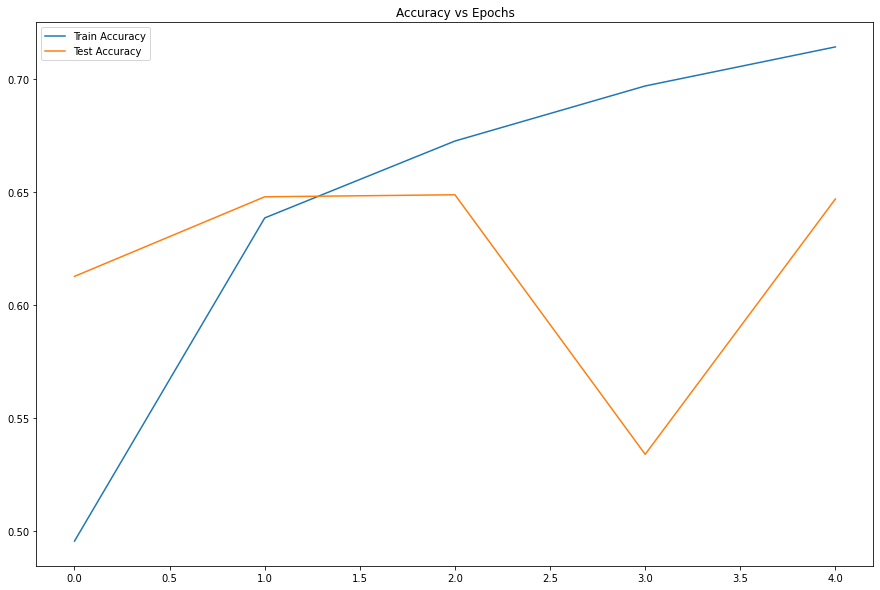

In [ ]:
plt.figure(figsize=(15,10))
plt.title("Accuracy vs Epochs")
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend(loc='best')
plt.show()

In [ ]:
model.evaluate(x_val, to_categorical(y_val))

488/488 [==============================] - 32s 66ms/step - loss: 0.9540 - accuracy: 0.6471


[0.9540139436721802, 0.6470588445663452]

* Predict test data

In [ ]:
test_data = Preprocess(test)
test['Sentiment'] = np.argmax(model.predict(test_data), axis=1)

2072/2072 [==============================] - 135s 65ms/step
